### 状態空間モデル

+ 観測方程式 (尤度)
$$ \boldsymbol{y}_{t} = \boldsymbol{Z}_{t}\boldsymbol{\alpha}_{t} + \boldsymbol{\epsilon}_{t} $$
+ 状態方程式 (階層事前分布)
$$ \boldsymbol{\alpha}_{t+1} = \boldsymbol{T}_{t}\boldsymbol{\alpha}_{t} + \boldsymbol{\eta}_{t} $$

#### 観測方程式と状態方程式がガウス分布に従う場合の誤差項
+ 観測方程式の誤差項 $ \boldsymbol{\epsilon}_{t} $
$$ \boldsymbol{\epsilon}_{t} = \boldsymbol{G}_{t}\boldsymbol{u}_{t} $$
+ 状態方程式の誤差項 $ \boldsymbol{\eta}_{t} $
$$ \boldsymbol{\eta}_{t} = \boldsymbol{H}_{t}\boldsymbol{u}_{t} $$
+ 誤差項に関する潜在確率変数は, i.i.dのガウス分布に従う
$$ \boldsymbol{u}_{t} \sim N(\boldsymbol{0}, \boldsymbol{I}) $$

#### 観測方程式と状態方程式がガウス分布に従う場合の周辺確率分布
+ 観測方程式がガウス分布に従う場合
$$ \boldsymbol{y}_{1} \sim N_m(\boldsymbol{Z}_{1}\boldsymbol{\alpha}_{1}, \boldsymbol{G}_{1}\boldsymbol{G}_{1}^{T}) $$
+ 状態方程式がガウス分布に従う場合
$$ \boldsymbol{\alpha}_{1} \sim N_r(\boldsymbol{T}_{0}\boldsymbol{\alpha}_{0}, \boldsymbol{H}_{0}\boldsymbol{H}_{0}^{T}) $$

#### ガウス分布に従う観測方程式と状態方程式
$$ \boldsymbol{y}_{t} = \boldsymbol{Z}_{t}\boldsymbol{\alpha}_{t} + \boldsymbol{G}_{t}\boldsymbol{u}_{t} $$
$$ \boldsymbol{\alpha}_{t+1} = \boldsymbol{T}_{t}\boldsymbol{\alpha}_{t} + \boldsymbol{H}_{t}\boldsymbol{u}_{t} $$



#### $ \boldsymbol{y}_{t} $ と $ \boldsymbol{\alpha}_{t+1} $ の同時分布

$$ 
\begin{bmatrix}
    \boldsymbol{y}_{t} \\
    \boldsymbol{\alpha}_{t+1}
\end{bmatrix} | \boldsymbol{\alpha}_{t}
\sim
N_{m+r}(
    \begin{bmatrix}
        \boldsymbol{Z}_{t}\boldsymbol{\alpha}_{t} \\ 
        \boldsymbol{T}_{t}\boldsymbol{\alpha}_{t}
    \end{bmatrix},
    \begin{bmatrix} 
        \boldsymbol{G}_{t}\boldsymbol{G}_{t}^T, \boldsymbol{G}_{t}\boldsymbol{H}_{t}^T \\ 
        \boldsymbol{H}_{t}\boldsymbol{G}_{t}^T, \boldsymbol{H}_{t}\boldsymbol{H}_{t}^T
    \end{bmatrix}
)

#### 状態空間モデルに関する推論
1. フィルタリング : $ \boldsymbol{\alpha} $ を $ \boldsymbol{y}_{1:n} $ から推論する
2. 予測 : 将来の $ \boldsymbol{\alpha}_{s} $ と $ \boldsymbol{y}_{s} $  ($ (s > t) $) を $ \boldsymbol{y}_{1:n} $ に基づき推論する
3. 平滑化(スムージング) : 観測されなかった $ \boldsymbol{\alpha}_{t} (t=1, \cdots n) $ の値を全標本期間のデータ $ \boldsymbol{y}_{1:n} $ に基づき推論する (目的は, 過去の状態を知ること)
4. パラメータの推定 : フィルタリング, 予測, 平滑化 ではなく, 状態空間モデル内部で使用するパラメータ $ \theta $ を推定すること

フィルタリング
$$ p(\alpha_t | y_{1:n}) = p(\alpha_t | y_t, y_{1:t-1}) = \frac{p(y_t|\alpha_t) p(\alpha_t|y_{1:t-1})}{p(y_t|y_{1:t-1})} $$
$$ p(y_t | y_{1:t-1}) = \int_{A} p(y_t | \alpha_t) p(\alpha_t | y_{1:t-1}) d\alpha_t $$

1期先予測分布
+ $ p(\alpha_t | y_{1:t}) $
+ $ p(y_t | y_{1:t-1}) $

$$ p(\alpha_{t+1} | y_{1:t}) = \int_{A} p(\alpha_{t+1} | \alpha_{t}, y_{1:t}) p(\alpha_t | y_{1:t})d\alpha_t $$ 
を用いて, 時点tにおける $\alpha_t$ の事後分布 $p(\alpha_t|y_{1:t})$ から時点t+1における $\alpha_{t+1}$ の事前分布 $p(\alpha_{t+1}|y_{1:t})$ を求めることができる

### ベイズフィルタ
+ $p(\alpha_{1})$
+ $p(\alpha_{t}|y_{1:t-1})$
+ $p(y_t|y_{1:t-1})$
+ $p(\alpha_t|y_{1:t}) $

### カルマンフィルタ
+ 誤差パラメータ(潜在確率変数) $\boldsymbol{u}_{t}$ にガウス分布を想定している場合

### カルマンスムーザー
$$ p(\alpha_{t}|y_{1:n}) = \int_{A}p(\alpha_t|\alpha_{t+1},y_{1:n})p(\alpha_{t+1}|y_{1:n})d\alpha_{t+1} = \int_{A}p(\alpha_t|\alpha_{t+1},y_{t})p(\alpha_{t+1}|y_{1:n})d\alpha_{t+1} $$

#### 状態空間モデルにおける未知パラメータ$\theta$の推定

+ パラメータ$\theta$の事前分布$p(\theta)$
$$ p(\theta) $$

+ 状態空間モデルのパラメータ$\theta$に関する尤度には, 時系列データ$y_{1:n}$と状態変数$\alpha_{1:n+1}$ の当時分布が必要
$$ p(y_{1:n}, \alpha_{1:n+1} | \theta) = p(\alpha_1) \Pi_{t=1}^{n} p(y_t, \alpha_{t+1} | \alpha_t, \theta) $$

+ $\alpha_{1:n+1}$を消す
$$ p(y_{1:t} | \theta) = \int_{A} \cdots \int_{A} p(y_{1:n}, \alpha_{1:n+1} | \theta) d\alpha_1 \cdots d\alpha_{n+1} = \int_{A} \cdots \int_{A} p(\alpha_1) \Pi_{t=1}^{n} p(y_t, \alpha_{t+1} | \alpha_t, \theta) d\alpha_1 \cdots d\alpha_{n+1} $$

+ ベイスフィルタで $\alpha_{1:n+1}$ を消すことができる
+ 状態空間モデルの尤度が計算できる
$$ p(y_{1:n} | \theta) = p(y_1 | \theta) \Pi_{t=2}^{T} p(y_t | y_{1:t-1}, \theta) $$

+ ベイズの定理を適用して$\theta$の事後分布を計算
$$ p(\theta | y_{1:n}) \propto p(y_{1:n} | \theta) p(\theta) $$

+ ベイズフィルタがカルマンフィルタの場合
+ $p(y_1 | \theta)$と$p(y_t | y_{1:t-1}, \theta)$は, カルマンフィルタの1期先予測で計算できる

## ノイズを含むAR(1)過程

In [2]:
import numpy as np
import scipy.stats as st
import scipy.linalg as la
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
%matplotlib inline
import japanize_matplotlib

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/pymc/distributions/timeseries.py:592: FutureWarning: init parameter is now called init_dist. Using init will raise an error in a future release.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, rho, omega, ar1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (503) in plot_autocorr, generating only 40 plots
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ar1[0],0.397,0.372,-0.318,1.065,0.006,0.005,3575.0,3001.0,1.00
ar1[1],0.880,0.326,0.276,1.476,0.005,0.004,3696.0,3277.0,1.00
ar1[2],1.100,0.327,0.473,1.700,0.006,0.004,3153.0,2873.0,1.00
ar1[3],0.882,0.321,0.256,1.453,0.005,0.004,3972.0,3249.0,1.00
ar1[4],1.024,0.318,0.435,1.624,0.005,0.004,3536.0,3014.0,1.00
...,...,...,...,...,...,...,...,...,...
ar1[498],0.738,0.328,0.112,1.330,0.006,0.004,3497.0,2933.0,1.00
ar1[499],1.144,0.379,0.416,1.830,0.008,0.006,2455.0,3080.0,1.00
sigma,0.515,0.031,0.459,0.575,0.001,0.001,498.0,772.0,1.01
rho,0.924,0.021,0.884,0.962,0.001,0.001,604.0,1432.0,1.01


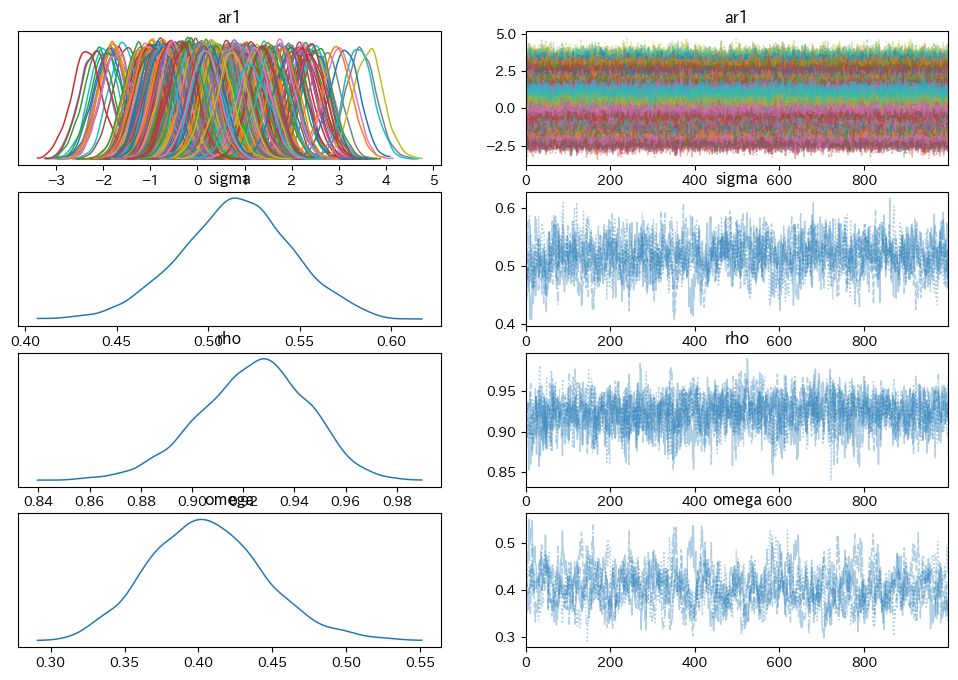

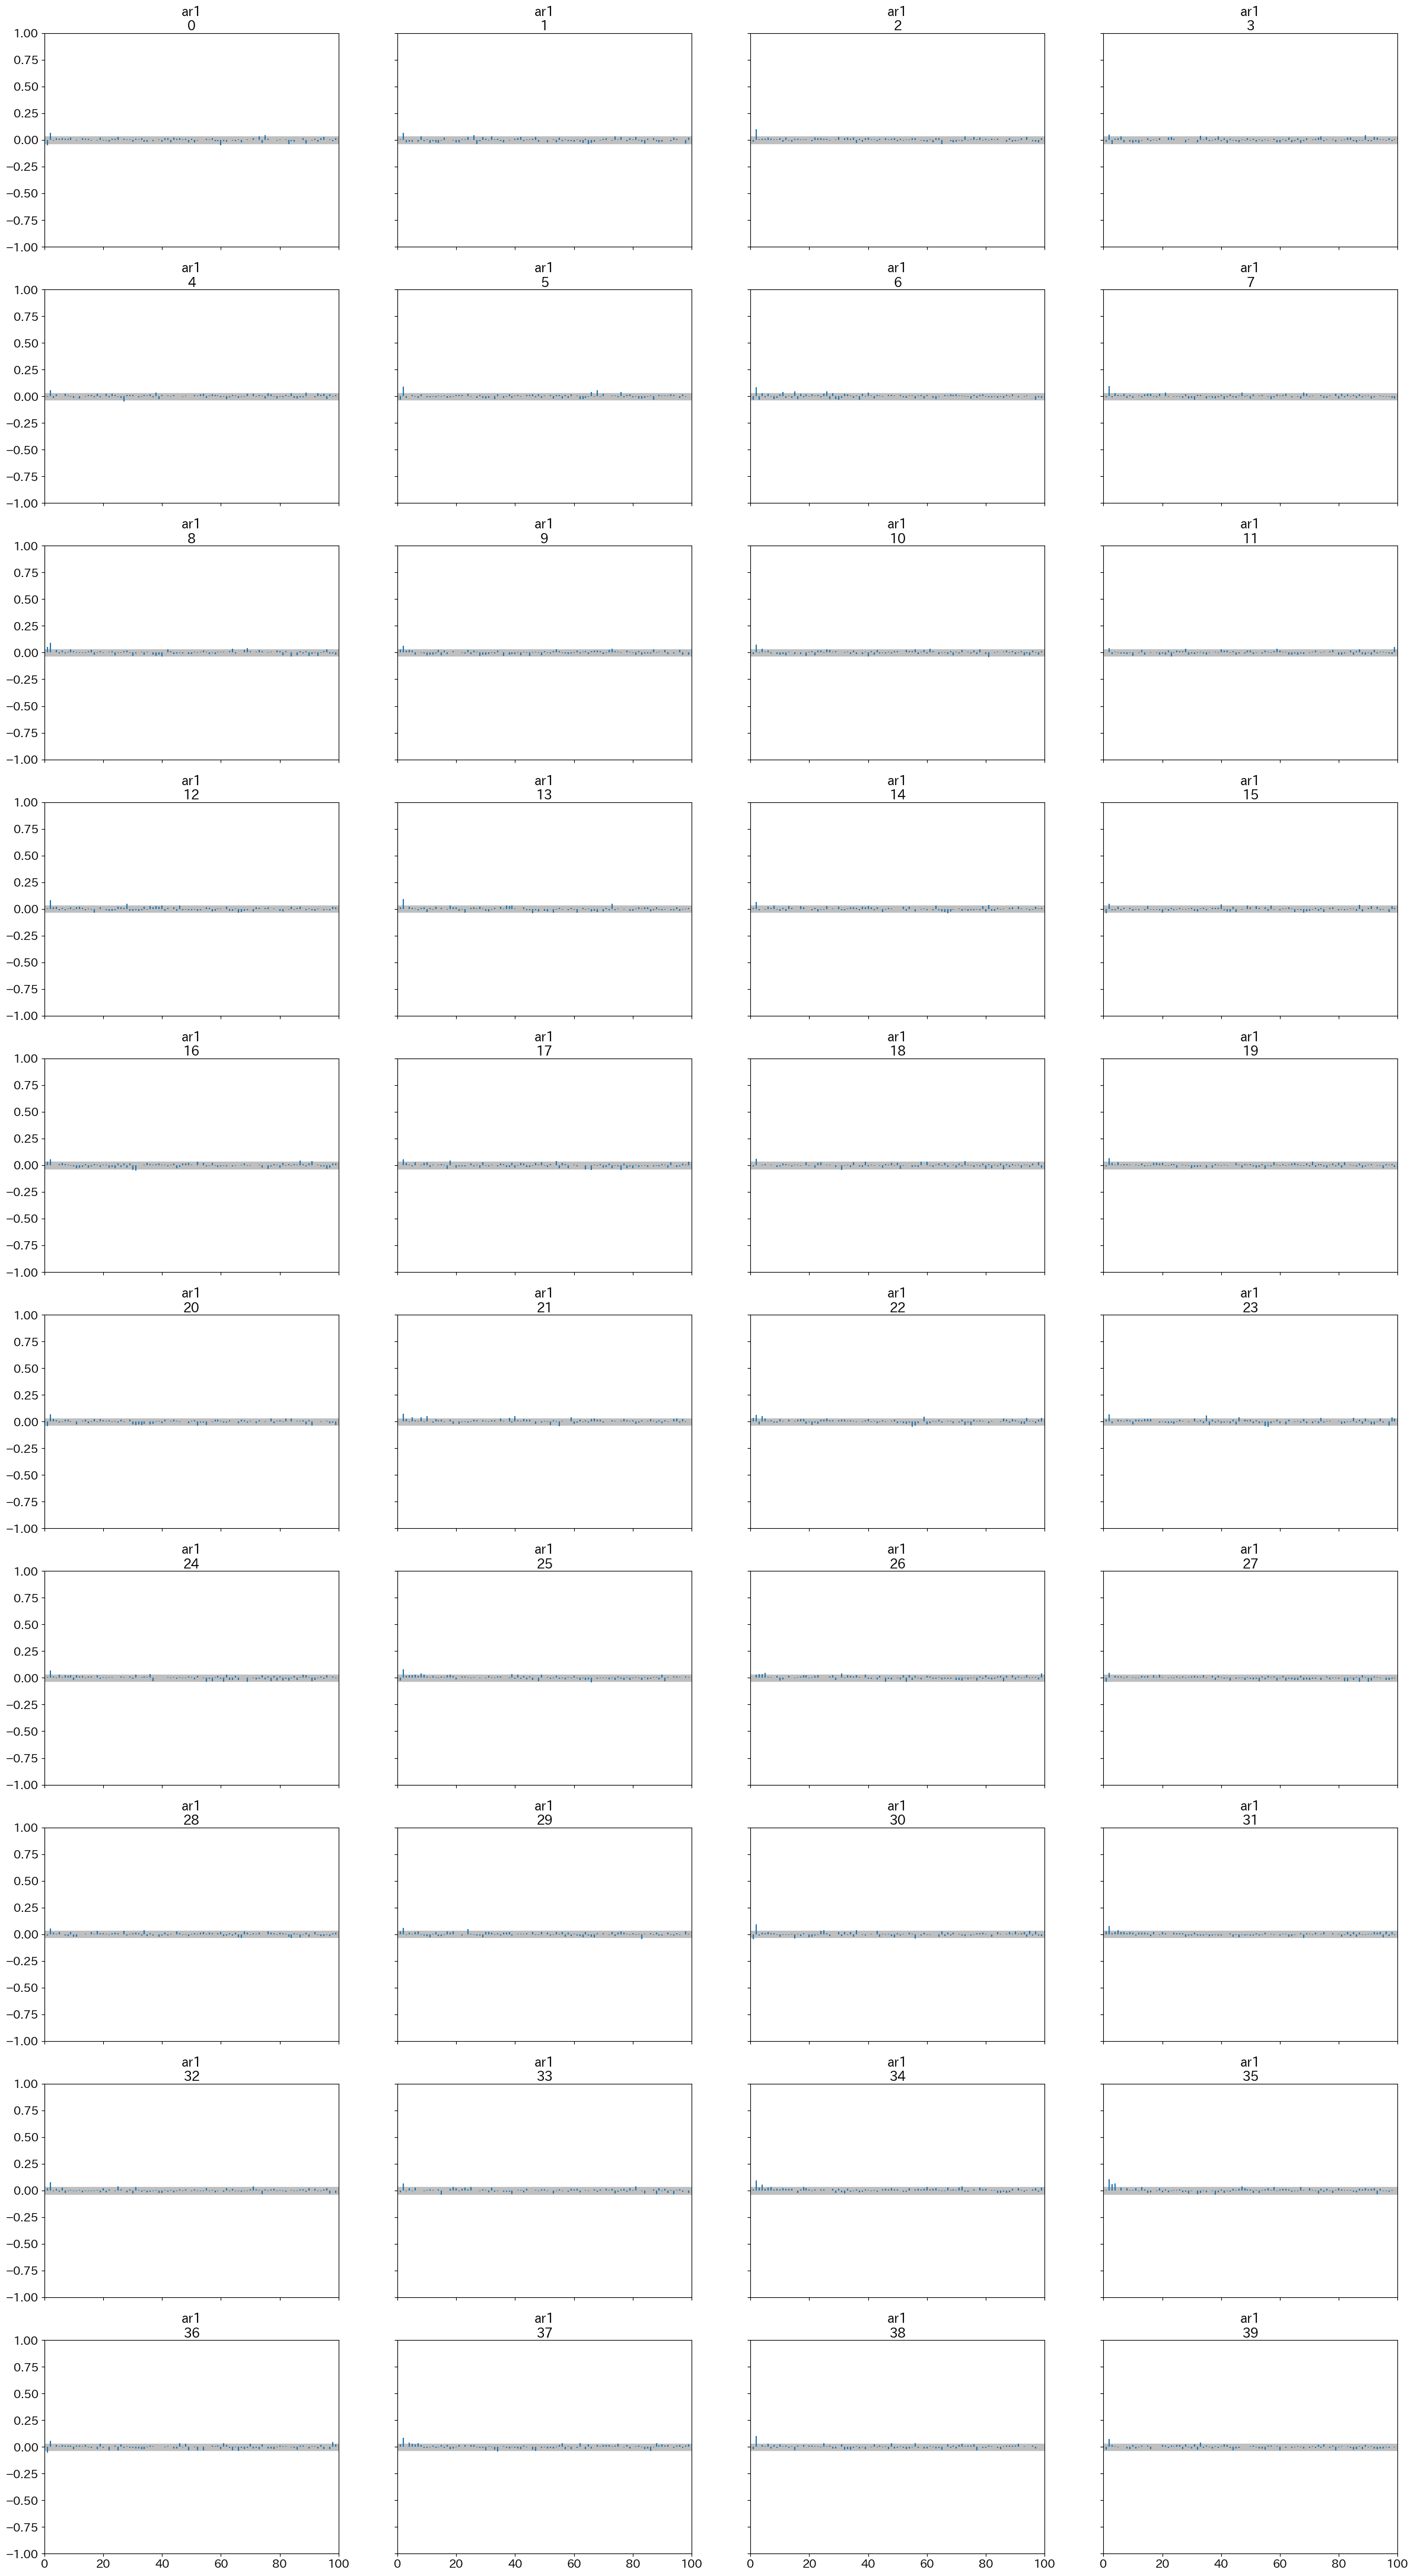

In [2]:
# ノイズを含むAR(1)過程からデータを生成
n = 500
np.random.seed(99)
x = np.empty(n)
x[0] = st.norm.rvs() # 定常分布の分散 = 0.19 / (1 - 0.9**2) = 1.0
for t in range(1, n):
    x[t] = 0.9 * x[t-1] + st.norm.rvs(scale=np.sqrt(0.19))
y = x + st.norm.rvs(scale=0.5, size=n)

# 事後分布の設定
ar1_model = pm.Model()
with ar1_model:
    sigma = pm.HalfCauchy('sigma', beta=1.0) # 観測方程式の誤差項の標準偏差
    rho = pm.Uniform('rho', lower=-1.0, upper=1.0) # 状態方程式の係数T_t
    omega = pm.HalfCauchy('omega', beta=1.0) # 状態方程式の誤差項の標準偏差
    ar1 = pm.AR('ar1', rho, sigma=omega, shape=n, init=pm.Normal.dist(mu=0, sigma=omega/pm.math.sqrt(1-rho**2))) # 状態方程式
    observation = pm.Normal('y', mu=ar1, sigma=sigma, observed=y)

# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 1000
with ar1_model:
    trace = pm.sample(draw=n_draws, chains=n_chains, tune=n_tune, random_seed=123)


az.plot_trace(trace, combined=True) # 事後分布の可視化
az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
az.summary(trace) # 事後統計量

### 使用電力量のトレンドと季節変動

[53.14409237 53.01053452 53.45811032 53.17276521 53.32648603 53.19861826
 53.76743192 53.32978225 53.52264351 53.36028223 53.79920801 53.42476031
 53.61127454 53.38299452 53.80171972 53.4583236  53.66500611 53.47791785
 53.70995067 53.47750089 53.7385684  53.52609936 54.17707832 53.63658292
 53.86017224 53.61988214 54.13034865 53.713227   54.01651508 53.74838773
 54.15782792 53.81308122 54.04948864 53.80607294 54.28599434 53.85593516
 54.07695273 53.8489684  54.31022191 53.9064983  54.07604246 53.85532675
 54.35291513 53.98032511 54.21112641 53.93515592 54.48775094 54.02034848
 54.25777751 53.93408352 54.42982866 53.97725402 54.1637546  53.90524018
 54.45273873 54.06914614 54.32077236 53.98205625 54.32251116 54.03218139
 54.32692906 54.0523367  54.56171476 54.0808604  54.39686028 54.0840533
 54.53658975 54.20002725 54.50570678 54.1688175  54.56968081 54.2343937
 54.45740239 54.22369405 54.62328709 54.33835422 54.63944172 54.22792809
 54.63284229 54.23620135 54.32340456 54.00352467 54.3

/tmp/ipykernel_67452/1929687900.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  series_date = pd.date_range(start='1/1/1989', periods=n, freq='Q')
/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/pymc/distributions/timeseries.py:621: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/pymc/distributions/timeseries.py:621: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100, shape=...)`. You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, tau, omega, trend, seasonal]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 74 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (221) in plot_autocorr, generating only 40 plots
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
trend[0],-0.134,4.280,-7.861,8.171,0.217,0.153,394.0,1984.0,1.01
trend[1],4.537,3.356,-1.718,10.994,0.135,0.096,605.0,1936.0,1.01
trend[2],9.202,2.728,4.051,14.299,0.071,0.050,1474.0,2429.0,1.00
trend[3],13.820,2.391,9.253,18.107,0.039,0.028,3744.0,3030.0,1.00
trend[4],18.300,2.299,13.900,22.446,0.059,0.041,1537.0,675.0,1.00
...,...,...,...,...,...,...,...,...,...
seasonal[107],-16.386,2.846,-21.470,-10.875,0.045,0.032,3914.0,3296.0,1.00
seasonal[108],24.597,3.311,18.173,30.533,0.101,0.071,1083.0,2148.0,1.00
sigma,6.138,0.630,4.923,7.287,0.037,0.027,281.0,560.0,1.01
tau,0.738,0.339,0.246,1.362,0.037,0.026,65.0,37.0,1.06


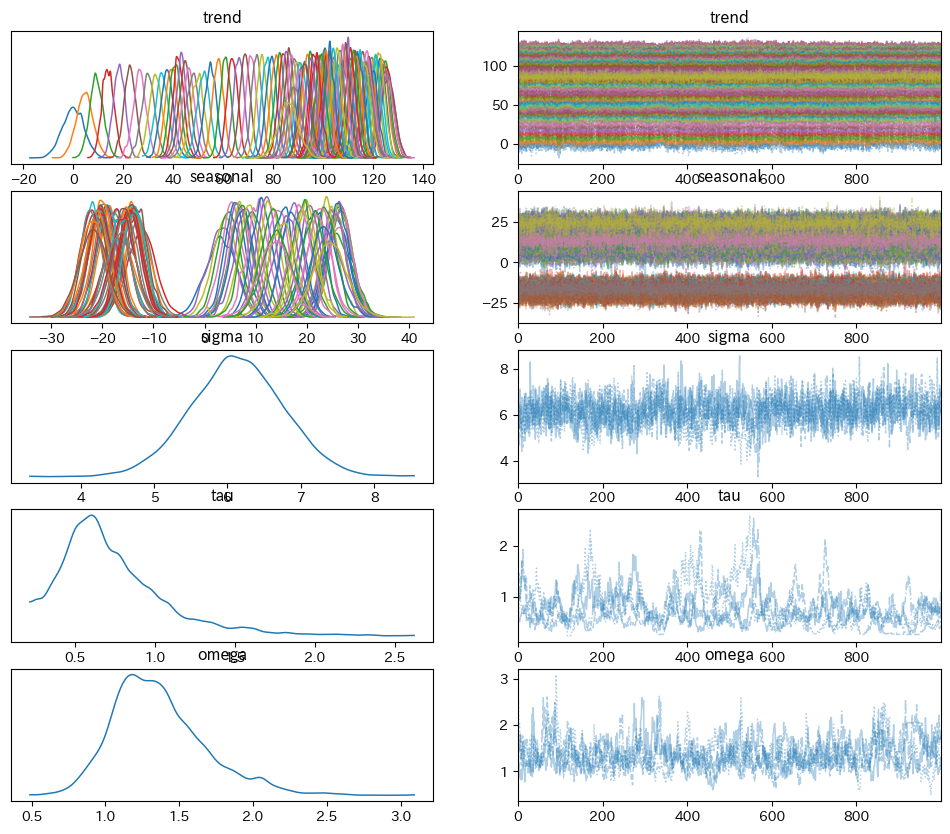

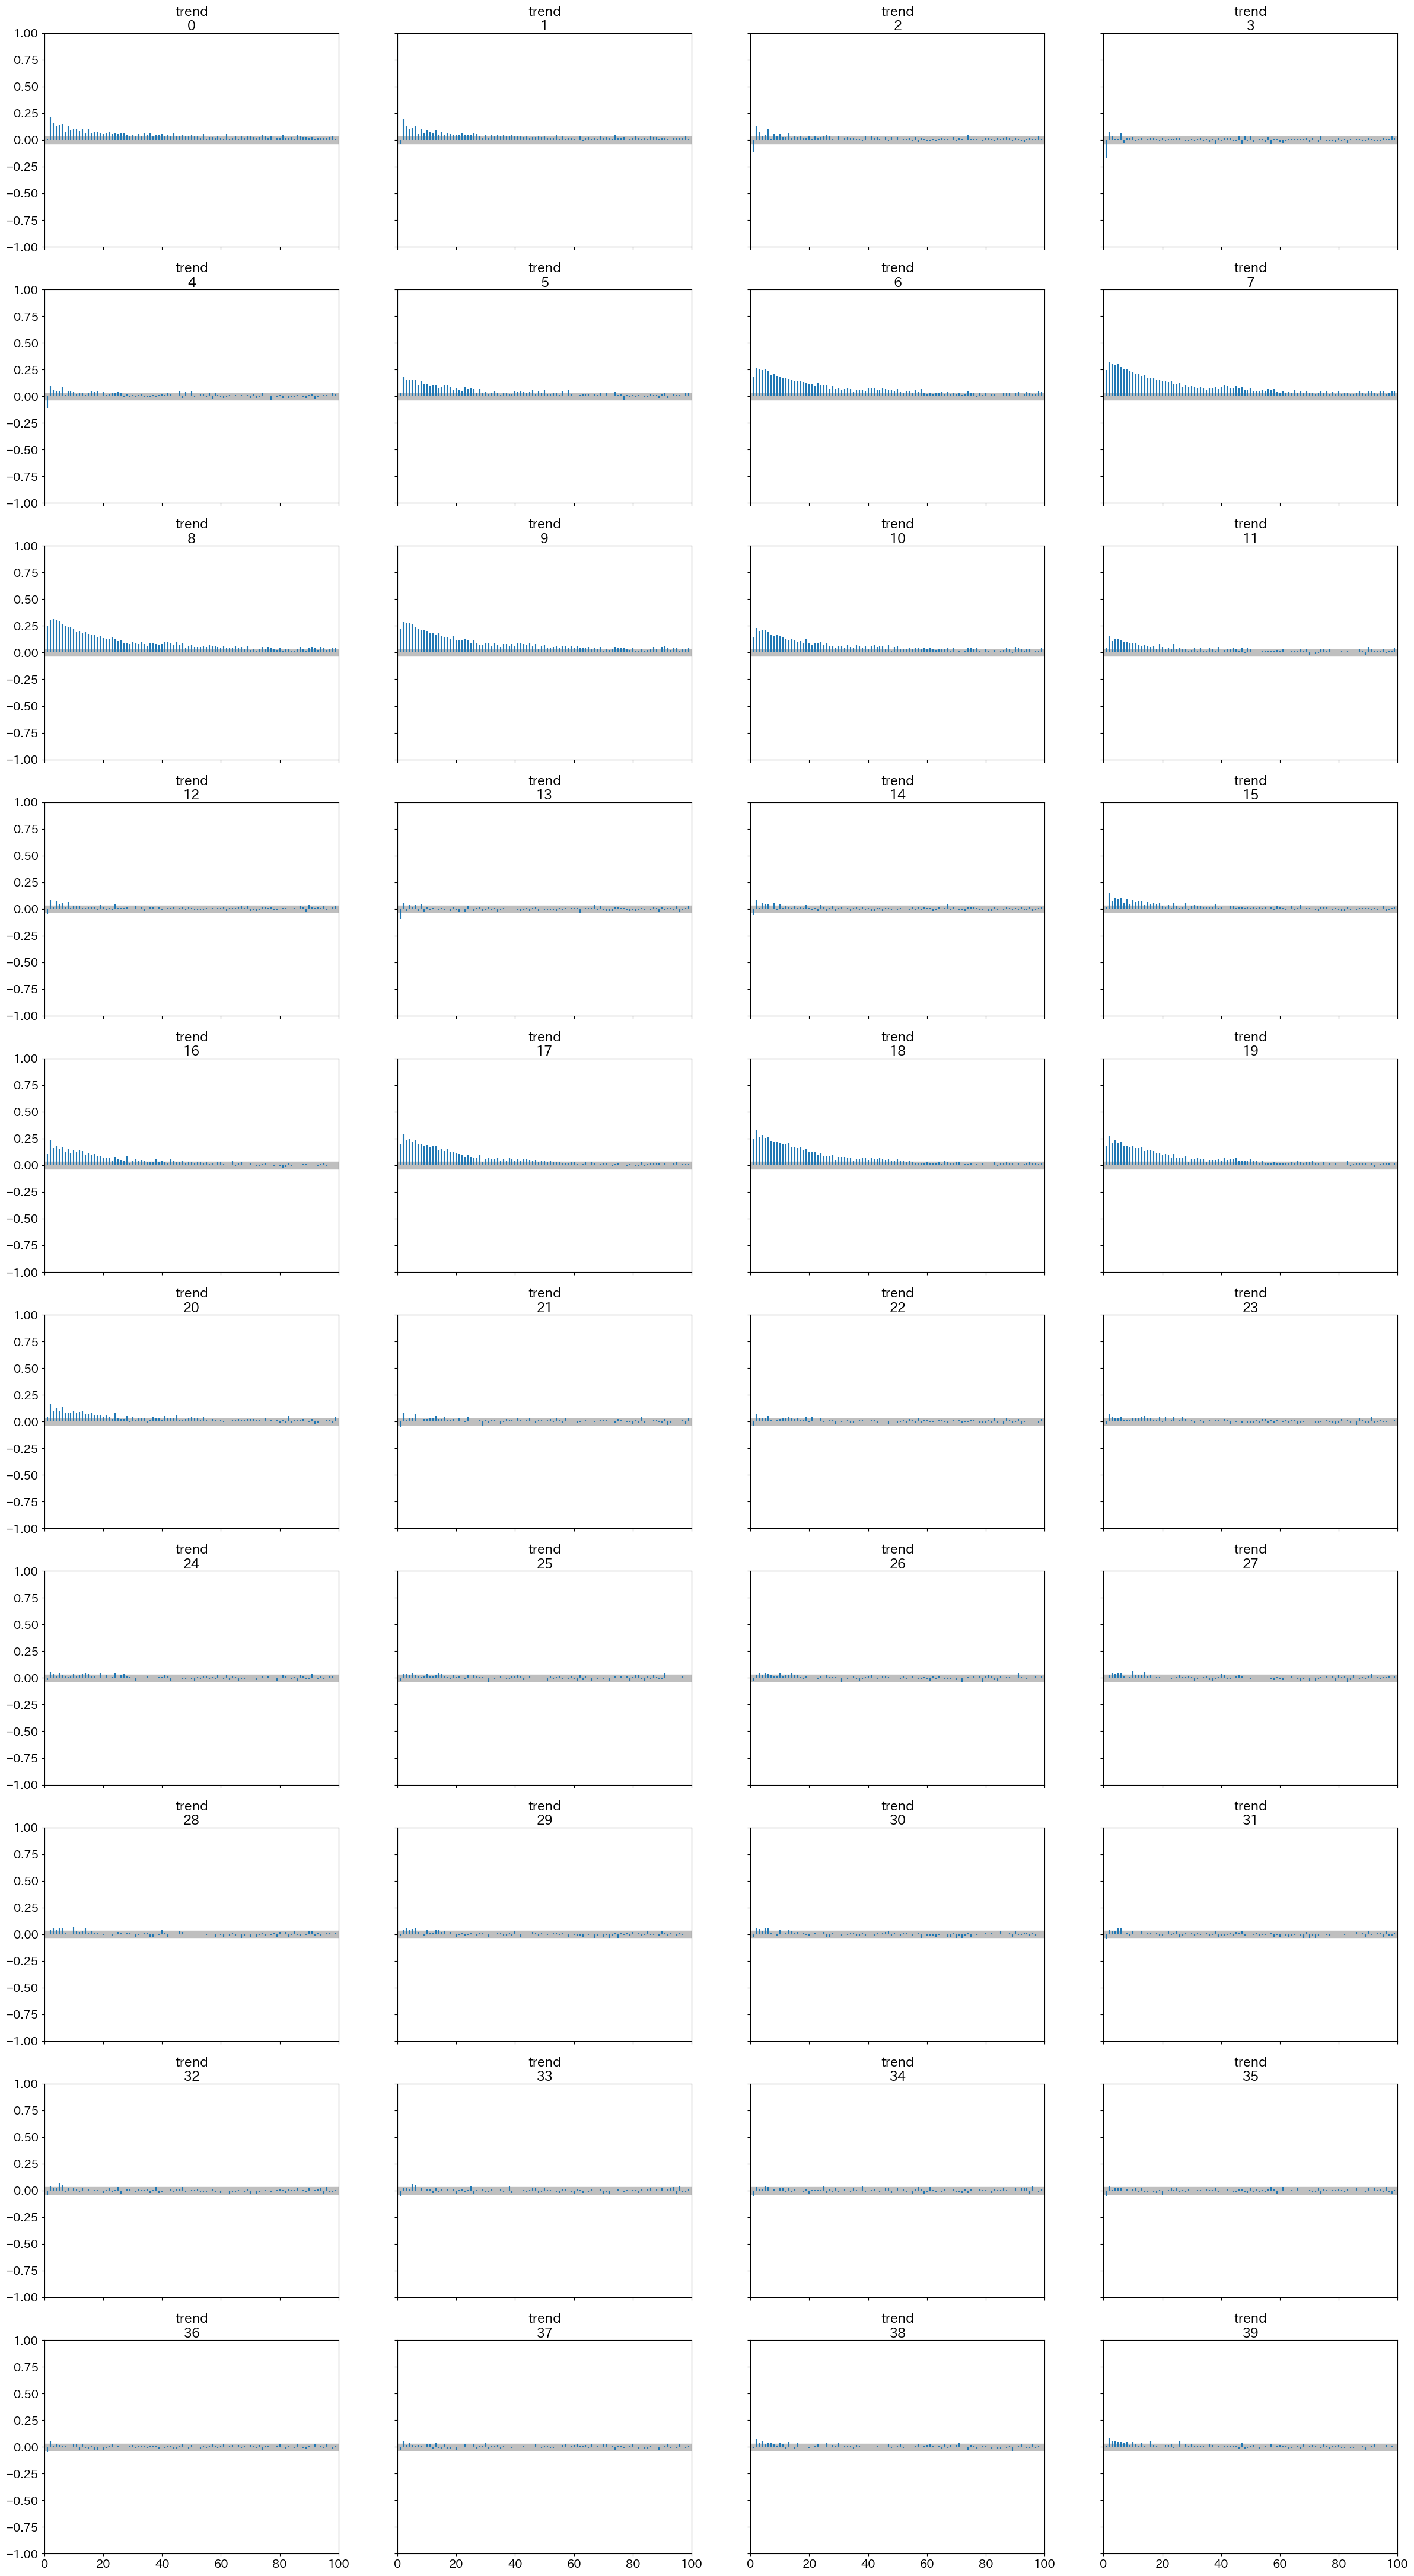

In [27]:
import pandas as pd

data = pd.read_csv('data/electricity.csv', index_col=0)
y0 = np.log(data.values.reshape((data.shape[0]//3, 3))).sum(axis=1)
print(y0)
y = 100 * (y0 - y0[0])
n = y.size
series_date = pd.date_range(start='1/1/1989', periods=n, freq='Q')

# 確率的トレンド + 季節変動
trend_coef = np.array([2.0, -1.0]) # μ[t+1] = 2μ[t] - μ[t-1] + η[t]
seasonal_coef = np.array([-1.0, -1.0, -1.0]) # c[t+1] = -c[t] - c[t-1] - c[t-2] + ν[t]
timeseries_decomp = pm.Model()
with timeseries_decomp:
    sigma = pm.HalfCauchy('sigma', beta=1.0)
    tau = pm.HalfCauchy('tau', beta=1.0)
    omega = pm.HalfCauchy('omega', beta=1.0)
    trend = pm.AR('trend', trend_coef, sigma=tau, shape=n) # 状態方程式の一部
    seasonal = pm.AR('seasonal', seasonal_coef, sigma=omega, shape=n) # 状態方程式の一部
    observation = pm.Normal('y', mu=trend+seasonal, sigma=sigma, observed=y)

# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 2000
with timeseries_decomp:
    trace = pm.sample(draw=n_draws, 
                      chains=n_chains, 
                      tune=n_tune, 
                      random_seed=123, 
                      nuts_kwargs=dict(target_accept=0.9))


az.plot_trace(trace, combined=True) # 事後分布の可視化
az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
az.summary(trace) # 事後統計量


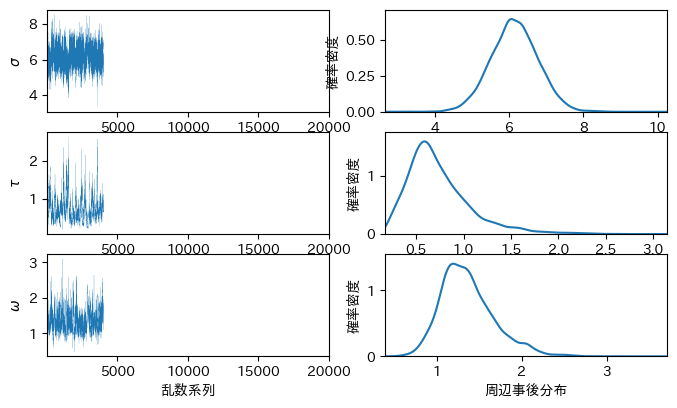

In [28]:
param_names = ['sigma', 'tau', 'omega']
# print(pm.summary(trace))

# 事後分布のグラフ作図
series_name = ['原系列', '平滑値', 'トレンド', '季節変動', 'ノイズ']
labels = ["$\\sigma$", "$\\tau$", "$\\omega$"]
k = len(labels)
fig1, ax1 = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k))
for index in range(k):
    mc_trace = trace.posterior[param_names[index]].values.flatten()
    x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
    x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
    x = np.linspace(x_min, x_max, 250)
    posterior = st.gaussian_kde(mc_trace).evaluate(x)
    ax1[index,0].plot(mc_trace, '-', linewidth=0.1)
    ax1[index,0].set_xlim(1, n_draws*n_chains)
    ax1[index,0].set_ylabel(labels[index])
    ax1[index,1].plot(x, posterior, '-')
    ax1[index,1].set_xlim(x_min, x_max)
    ax1[index,1].set_ylim(0, 1.1 * posterior.max())
    ax1[index,1].set_ylabel('確率密度')
ax1[k-1,0].set_xlabel('乱数系列')
ax1[k-1,1].set_xlabel('周辺事後分布')
# plt.tight_layout()
plt.show()

In [29]:
trace.posterior['trend']

<xarray.DataArray 'trend' (chain: 4, draw: 1000, trend_dim_0: 109)> Size: 3MB
array([[[-2.94515572,  1.34384709,  6.46357071, ..., 90.77380004,
         88.86796375, 87.63344214],
        [ 7.44107758,  9.57240678, 12.16823537, ..., 87.61304349,
         83.95960761, 80.89708547],
        [-4.13912803,  1.06665244,  6.07150983, ..., 92.98276225,
         91.40662271, 90.58084202],
        ...,
        [ 1.07016838,  5.70450659, 10.12805571, ..., 91.35473007,
         89.60580995, 88.21758664],
        [-0.96386871,  4.43777136, 10.21167334, ..., 90.68472126,
         87.59587793, 83.65888009],
        [-1.55350188,  2.70533156,  6.17006195, ..., 91.80462032,
         90.23320813, 88.50865857]],

       [[-1.75562055,  3.64588546,  8.69650144, ..., 92.10492455,
         88.03077894, 83.86416641],
        [10.2215062 , 14.04909298, 16.54724285, ..., 92.0662631 ,
         90.88275206, 90.31297649],
        [-3.50323756,  3.42905205,  9.40317224, ..., 89.65027385,
         86.09994016, 81.80353979],
...
        [-4.00135008,  1.02452188,  5.58046175, ..., 91.9556007 ,
         91.07842722, 90.083414  ],
        [ 9.45078601, 12.5170958 , 15.10118297, ..., 90.84815671,
         88.99971858, 87.37782255],
        [-3.93858837,  1.70716311,  7.12419104, ..., 89.79093135,
         87.59941041, 86.13148411]],

       [[ 4.70774922,  9.35008301, 14.2164943 , ..., 92.40063015,
         90.97074084, 90.22610794],
        [-8.25302372, -3.09730013,  2.5547849 , ..., 89.66961702,
         86.11893099, 83.92266863],
        [-6.54304028, -1.25504899,  6.01514584, ..., 89.91585785,
         88.44529427, 85.52839946],
        ...,
        [ 4.65423985,  8.22936397, 11.65252282, ..., 95.18806349,
         93.21478639, 89.77000121],
        [ 5.12074427,  9.80425952, 13.65820721, ..., 84.95889312,
         79.72801108, 75.27644153],
        [-6.86226211, -0.43659207,  5.57041981, ..., 95.2879178 ,
         90.93809328, 87.64849597]]])
Coordinates:
  * chain        (chain) int64 32B 0 1 2 3
  * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
  * trend_dim_0  (trend_dim_0) int64 872B 0 1 2 3 4 5 ... 104 105 106 107 108

(4000, 109)
(109,)
(4000, 109)
(109,)
(109,)
(109, 5)
                   原系列         平滑値       トレンド       季節変動       ノイズ
1989-03-31    0.000000    3.025740  -0.134161   3.159901 -3.025740
1989-06-30  -13.355785  -12.367592   4.536622 -16.904215 -0.988193
1989-09-30   31.401794   35.108627   9.201984  25.906643 -3.706832
1989-12-31    2.867283    1.523803  13.819664 -12.295861  1.343480
1990-03-31   18.239366   21.633256  18.299823   3.333434 -3.393891
...                ...         ...        ...        ...       ...
2015-03-31  124.561776  119.193653  94.984484  24.209169  5.368123
2015-06-30   72.974936   70.882149  92.792376 -21.910227  2.092786
2015-09-30   99.730869  104.287903  90.512004  13.775899 -4.557034
2015-12-31   67.615113   71.853142  88.238751 -16.385610 -4.238029
2016-03-31  112.675914  110.611855  86.014572  24.597283  2.064059

[109 rows x 5 columns]


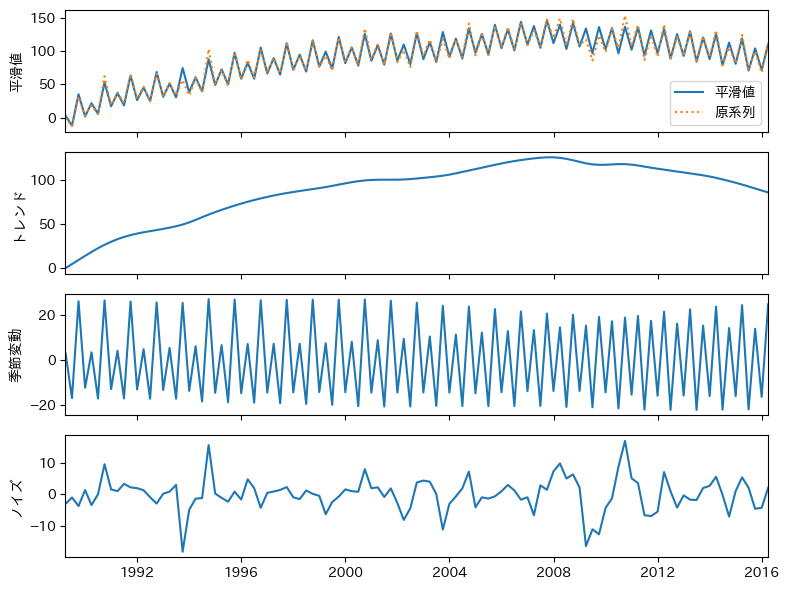

In [31]:
# 原系列を確率的トレンド, 季節変動, ノイズに分解

trend = trace.posterior['trend'].values
trend = trend.reshape(-1, trend.shape[-1])
print(trend.shape)
m_trend = trend.mean(axis=0)
print(m_trend.shape)

seasonal = trace.posterior['seasonal'].values
seasonal = seasonal.reshape(-1, seasonal.shape[-1])
print(seasonal.shape)
m_seasonal = seasonal.mean(axis=0)
print(m_seasonal.shape)

noise = y - m_trend - m_seasonal
print(noise.shape)

series = np.vstack((y, m_trend + m_seasonal, m_trend, m_seasonal, noise)).T
print(series.shape)
results = pd.DataFrame(series, index=series_date, columns=series_name)
print(results)

fig2, ax2 = plt.subplots(4, 1, sharex='col', num=2, figsize=(8, 6))
for index in range(4):
    ts_name = series_name[index+1]
    ax2[index].plot(results[ts_name], '-', label=ts_name)
    ax2[index].set_ylabel(ts_name)
ax2[0].plot(results[series_name[0]], ':', label=series_name[0])
ax2[0].set_xlim(series_date[0], series_date[-1])
ax2[0].legend(loc='lower right')
plt.tight_layout()
plt.show()

### 確率的ボラリティモデル

y.shape (998,)
DatetimeIndex(['2014-01-03', '2014-01-06', '2014-01-07', '2014-01-08',
               '2014-01-09', '2014-01-10', '2014-01-13', '2014-01-14',
               '2014-01-15', '2014-01-16',
               ...
               '2017-12-14', '2017-12-15', '2017-12-18', '2017-12-19',
               '2017-12-20', '2017-12-21', '2017-12-22', '2017-12-27',
               '2017-12-28', '2017-12-29'],
              dtype='datetime64[ns]', length=998, freq=None)


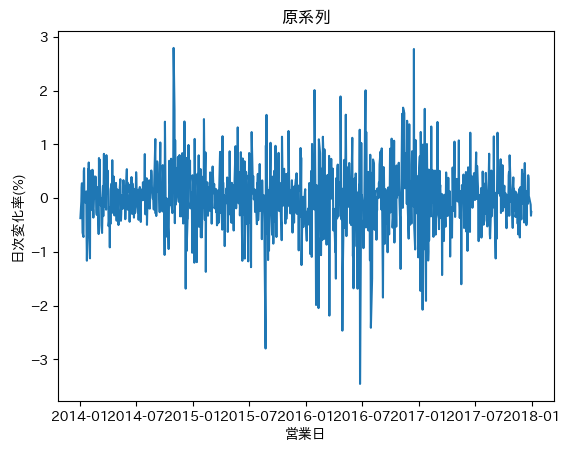

In [8]:
# ドル円為替レート日時データ
data = pd.read_csv('data/dollaryen.csv', index_col=0)
y = 100 * np.diff(np.log(data.values.ravel()))
print('y.shape', y.shape)
n = y.size
series_date = pd.to_datetime(data.index[1:])
print(series_date)

fig = plt.figure()
plt.plot(series_date, y)
plt.title('原系列')
plt.xlabel('営業日')
plt.ylabel('日次変化率(%)')
plt.show()

In [9]:
# SVモデルの設定
sv_model = pm.Model()
with sv_model:
    nu = pm.Exponential('nu', 0.2)
    sigma = pm.HalfCauchy('sigma', beta=1.0)
    rho = pm.Uniform('rho', lower=-1.0, upper=1.0)
    omega = pm.HalfCauchy('omega', beta=1.0)
    log_vol = pm.AR('log_vol', rho, sigma=omega, shape=n, init=pm.Normal.dist(sigma=omega/pm.math.sqrt(1-rho**2))) # 状態方程式
    observation = pm.StudentT('y', nu, sigma=sigma*pm.math.exp(log_vol)) # y = σExp(α_t)ε_t. 観測方程式

# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 2000
with sv_model:
    trace = pm.sample(draws=n_draws, 
                      chains=n_chains, 
                      tune=n_tune, 
                      random_seed=123, 
                      nuts_kwargs=dict(target_accept=0.9))

/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/pymc/distributions/timeseries.py:592: FutureWarning: init parameter is now called init_dist. Using init will raise an error in a future release.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [nu, sigma, rho, omega, log_vol, y]


Output()

Sampling 4 chains for 2_000 tune and 5_000 draw iterations (8_000 + 20_000 draws total) took 427 seconds.
There were 160 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
az.summary(trace) # 事後統計量

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_vol[0],-0.014,0.417,-0.790,0.856,0.035,0.045,105.0,114.0,1.15
log_vol[1],-0.076,0.429,-0.972,0.675,0.065,0.057,33.0,78.0,1.12
log_vol[2],0.090,0.513,-0.631,1.596,0.090,0.103,61.0,14.0,1.22
log_vol[3],-0.102,0.460,-1.015,0.740,0.072,0.062,32.0,48.0,1.14
log_vol[4],-0.011,0.397,-0.840,0.792,0.015,0.043,175.0,131.0,1.10
...,...,...,...,...,...,...,...,...,...
y[997],-0.089,6.184,-8.193,9.378,0.054,0.406,367.0,26.0,1.43
nu,6.775,4.834,1.008,15.465,0.276,0.195,74.0,77.0,1.17
sigma,2.029,3.273,0.059,7.756,1.352,1.008,5.0,15.0,2.40
rho,-0.040,0.477,-0.779,0.935,0.148,0.108,11.0,15.0,1.30


In [12]:
a = np.arange(5)
print(a)
tile = np.tile(a, (3, 1))
print(tile)
print(tile.T)


[0 1 2 3 4]
[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]
[[0 0 0]
 [1 1 1]
 [2 2 2]
 [3 3 3]
 [4 4 4]]


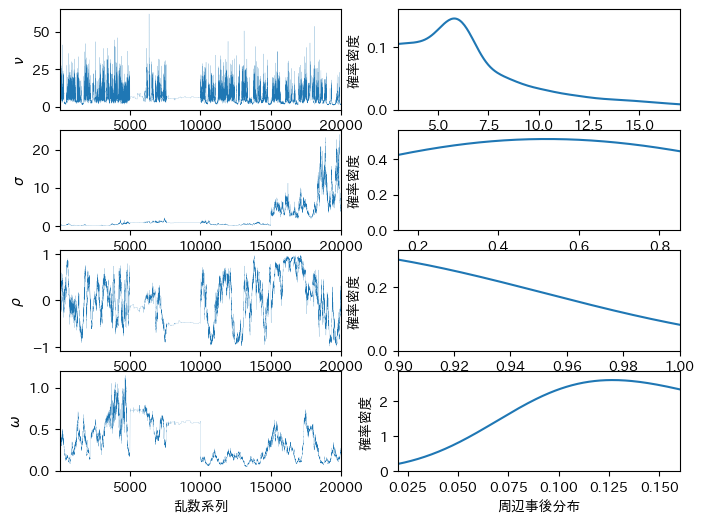

In [13]:
# 事後分布のグラフの作図
param_names = ['nu', 'sigma', 'rho', 'omega']
labels = ['$\\nu$', '$\\sigma$', '$\\rho$', '$\\omega$']
k = len(labels)

x_minimum = [3.0, 0.15, 0.9, 0.02]
x_maximum = [17.0, 0.85, 1.0, 0.16]

fig1, ax1 = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k))
for index in range(k):
    mc_trace = trace.posterior[param_names[index]].values.flatten()
    x_min = x_minimum[index]
    x_max = x_maximum[index]
    x = np.linspace(x_min, x_max, 250)
    posterior = st.gaussian_kde(mc_trace).evaluate(x)
    ax1[index,0].plot(mc_trace, '-', linewidth=0.1)
    ax1[index,0].set_xlim(1, n_draws*n_chains)
    ax1[index,0].set_ylabel(labels[index])
    ax1[index,1].plot(x, posterior, '-')
    ax1[index,1].set_xlim(x_min, x_max)
    ax1[index,1].set_ylim(0, 1.1 * posterior.max())
    ax1[index,1].set_ylabel('確率密度')
ax1[k-1,0].set_xlabel('乱数系列')
ax1[k-1,1].set_xlabel('周辺事後分布')
# plt.tight_layout()
plt.show()

MCMCがうまく行っていない

post_sigma.shape (20000, 998)
post_log_vol.shape (20000, 998)
post_obs.shape (998,)
y.shape (998,)


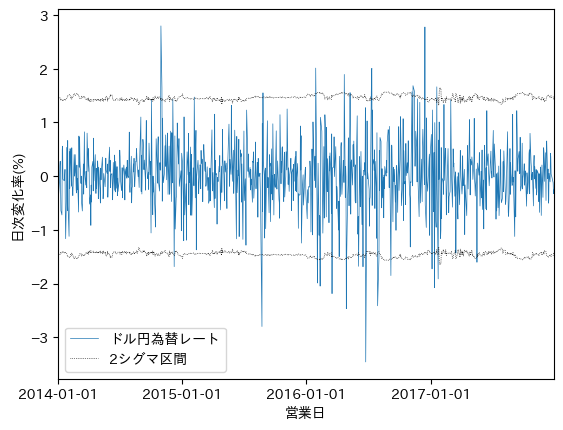

In [25]:
# ボラティリティのプロット
post_sigma = trace.posterior['sigma'].values.ravel()
post_sigma = np.tile(post_sigma, (n,1)).T
print('post_sigma.shape', post_sigma.shape)

post_log_vol = trace.posterior['log_vol'].values.ravel()
post_log_vol = post_log_vol.reshape(n, -1).T
print('post_log_vol.shape', post_log_vol.shape)

post_obs = post_sigma * np.exp(post_log_vol)
post_obs = np.median(post_obs, axis=0)
print('post_obs.shape', post_obs.shape)

print('y.shape', y.shape)

fig2 = plt.figure(num=2)
plt.plot(series_date, y, '-', linewidth=0.5, label="ドル円為替レート")
plt.plot(series_date, 2.0 * post_obs, 'k:', linewidth=0.5, label='2シグマ区間')
plt.plot(series_date, -2.0 * post_obs, 'k:', linewidth=0.5)
plt.xlim(series_date[0], series_date[-1])
plt.xticks(['2014', '2015', '2016', '2017'])
plt.xlabel('営業日')
plt.ylabel('日次変化率(%)')
plt.legend(loc='best')
plt.show()

In [17]:
998 * 20000

19960000